# Goldman Sachs Financial Risk Analysis

# Task 1: Data Cleaning and Formatting
* Remove/treat any special characters or non-numeric entries from financial fields.
* Convert currency amounts into numerical format.
* Validate and format date columns.
* Ensure account types and transaction categories are standardized.


In [1]:
# Import Important  Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats



In [2]:
# Load the dataset

df = pd.read_csv('goldman_sachs.csv')


In [3]:
df

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,33,CUST6549,ACC12334,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 1,21-10-2023,87480.05448,74008.43310,0.729101,319,200
1,177,CUST2942,ACC52650,Credit,Withdrawal,Home Loan,Firm A,East,Manager 3,20-06-2023,20315.74505,22715.83590,0.472424,692,47
2,178,CUST6776,ACC45101,Current,Deposit,Personal Loan,Firm C,South,Manager 3,02-01-2023,10484.57165,42706.09210,0.648784,543,109
3,173,CUST2539,ACC88252,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,25-07-2023,45122.27373,114176.56870,0.734832,430,103
4,67,CUST2626,ACC21878,Savings,Withdrawal,Home Loan,Firm C,Central,Manager 4,25-07-2023,42360.79878,17863.02644,0.289304,468,234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,11,CUST8461,ACC60432,Current,Withdrawal,Credit Card,Firm E,Central,Manager 3,17-02-2023,119878.30500,72041.03969,0.437613,772,217
796,44,CUST1121,ACC41829,Credit,Withdrawal,Personal Loan,Firm C,East,Manager 4,26-10-2023,97933.33752,98317.05068,0.240792,411,78
797,160,CUST3059,ACC28292,Current,Payment,Mutual Fund,Firm E,South,Manager 4,11-05-2023,63072.38174,35088.75351,0.283858,486,215
798,37,CUST1042,ACC28295,Current,Payment,Personal Loan,Firm E,West,Manager 3,26-03-2023,-25289.82472,40794.07619,0.515020,549,238


In [4]:
## Explore the dataset
print("-" * 80)
print("TASK 1: DATA CLEANING AND FORMATTING")
print("-" * 80)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nFirst five records:")
print(df.head())
print("\nColumn Data Types and other info:")
print(df.info())
print("-" * 80)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Values:")
print(df.duplicated().value_counts())

--------------------------------------------------------------------------------
TASK 1: DATA CLEANING AND FORMATTING
--------------------------------------------------------------------------------
Rows: 800, Columns: 15

First five records:
   TransactionID CustomerID AccountID AccountType TransactionType  \
0             33   CUST6549  ACC12334      Credit      Withdrawal   
1            177   CUST2942  ACC52650      Credit      Withdrawal   
2            178   CUST6776  ACC45101     Current         Deposit   
3            173   CUST2539  ACC88252     Current      Withdrawal   
4             67   CUST2626  ACC21878     Savings      Withdrawal   

           Product    Firm   Region    Manager TransactionDate  \
0  Savings Account  Firm C  Central  Manager 1      21-10-2023   
1        Home Loan  Firm A     East  Manager 3      20-06-2023   
2    Personal Loan  Firm C    South  Manager 3      02-01-2023   
3      Mutual Fund  Firm A  Central  Manager 2      25-07-2023   
4        Hom

In [5]:
#--------------------------------------------------------------------------------------------------------------------------------------
# Task: 1.1 - Remove/treat any special characters or non-numeric entries from financial fields ############
#--------------------------------------------------------------------------------------------------------------------------------------
# List of financial fields to clean
financial_fields = ['TransactionAmount', 'AccountBalance', 'RiskScore', 'CreditRating', 'TenureMonths']

for col in financial_fields:
    # Convert to string and use regex to remove everything except digits and decimal points
    # [^0-9.-] means: "Any character that is NOT a digit (0-9) or a period (.) and (-) contain negative sign"
    df[col] = df[col].astype(str).str.replace(r'[^0-9.-]', '', regex=True)
#--------------------------------------------------------------------------------------------------------------------------------------
# Task: 1.2 - Convert currency amounts into numerical format.   ######################
#--------------------------------------------------------------------------------------------------------------------------------------
    # Convert the cleaned strings to numeric (float/int) using pd.to_numeric()
    # errors='coerce' will turn any remaining invalid/empty values into NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove negative values from TransactionAmount coloum
df['TransactionAmount']=df['TransactionAmount'].abs()

print(f"\nDuplicate Values:\n{df.duplicated().value_counts()}")

# Handle missing values in financial columns (fill with 0 or median)
# Function: fillna() - replaces null values
#df[financial_columns] = df[financial_columns].fillna(df[financial_columns].median())

print("\n Financial fields converted to numerical format")
print('*'*50)
print(f'DataTypes :\n{df[financial_fields].dtypes}')
print('*'*50)




Duplicate Values:
False    800
Name: count, dtype: int64

 Financial fields converted to numerical format
**************************************************
DataTypes :
TransactionAmount    float64
AccountBalance       float64
RiskScore            float64
CreditRating           int64
TenureMonths           int64
dtype: object
**************************************************


In [6]:
############ Task: 1.3 - Validate and format date columns.   ################################
df['TransactionDate']=pd.to_datetime(df['TransactionDate'],dayfirst=True)
# To check the info of a single column
df["TransactionDate"].info()


<class 'pandas.core.series.Series'>
RangeIndex: 800 entries, 0 to 799
Series name: TransactionDate
Non-Null Count  Dtype         
--------------  -----         
800 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 6.4 KB


In [7]:
############## Task 1.4 -  Ensure account types and transaction categories are standardized. ###########################

#  Clean the Column Names
df.columns = df.columns.str.strip()

# Identify and clean only the String columns
text_colums = df.select_dtypes(include="object").columns
df[text_colums] = df[text_colums].apply(lambda s: s.str.strip())

# Standardized Account types and transaction categories .
df['AccountType']= df['AccountType'].str.strip().str.capitalize()
df['TransactionType'] = df['TransactionType'].str.strip().str.capitalize()
df['Region']= df['Region'].str.strip().str.capitalize()
# We can choose not to use str.strip() bcs we have already did this step in df[text_colums].apply(lambda s: s.str.strip())

print("\n Standardized Data")
print(f"\nUnique Account Types: {df['AccountType'].unique()}")
print(f"Unique Transaction Types: {df['TransactionType'].unique()}")
print(f"Unique Regions: {df['Region'].unique()}")


 Standardized Data

Unique Account Types: ['Credit' 'Current' 'Savings' 'Loan']
Unique Transaction Types: ['Withdrawal' 'Deposit' 'Payment' 'Transfer']
Unique Regions: ['Central' 'East' 'South' 'West' 'North']


# Task 2: Descriptive Transactional Analysis
* Calculate monthly and yearly summaries of total credits, debits, and net transaction volume.
* Plot trends in total credits vs. debits over time.
* Identify top and bottom performing accounts based on net inflow.
* Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.


In [8]:
############# Task 2.1 - Calculate monthly and yearly summaries of total credits, debits, and net transaction volume.##############

# Create Month Column
df['Month']=df['TransactionDate'].dt.month

# Create Year Column
df['Year']=df['TransactionDate'].dt.year

# Create Year-Month column
df['Year-Month'] = df['TransactionDate'].dt.to_period('M')

# Create Credit and Debit column
df["Credit"] = np.where(df['TransactionType'] == 'Deposit',1,0) # to get no. of credit
# by using np.where if the TransactionType is exactly 'Deposit', it puts a 1 in the new column otherwise it put a 0.
df['Credit_amount'] = np.where(df['Credit'] == 1,df['TransactionAmount'],0)

df['Debit']= np.where(df['TransactionType'].isin(['Withdrawal','Payment','Transfer']),1,0)
df['Debit_amount'] = np.where(df['Debit'] == 1,df['TransactionAmount'],0)
# Use np.where If Credit is 1, use TransactionAmount. Otherwise, use -TransactionAmount.
df["Net_Transaction_volume"] = np.where(df['Credit'] == 1,df['TransactionAmount'],-df['TransactionAmount'])


In [9]:
df.head(100)

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,CreditRating,TenureMonths,Month,Year,Year-Month,Credit,Credit_amount,Debit,Debit_amount,Net_Transaction_volume
0,33,CUST6549,ACC12334,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 1,2023-10-21,...,319,200,10,2023,2023-10,0,0.00000,1,87480.05448,-87480.05448
1,177,CUST2942,ACC52650,Credit,Withdrawal,Home Loan,Firm A,East,Manager 3,2023-06-20,...,692,47,6,2023,2023-06,0,0.00000,1,20315.74505,-20315.74505
2,178,CUST6776,ACC45101,Current,Deposit,Personal Loan,Firm C,South,Manager 3,2023-01-02,...,543,109,1,2023,2023-01,1,10484.57165,0,0.00000,10484.57165
3,173,CUST2539,ACC88252,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,2023-07-25,...,430,103,7,2023,2023-07,0,0.00000,1,45122.27373,-45122.27373
4,67,CUST2626,ACC21878,Savings,Withdrawal,Home Loan,Firm C,Central,Manager 4,2023-07-25,...,468,234,7,2023,2023-07,0,0.00000,1,42360.79878,-42360.79878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,63,CUST4346,ACC31902,Current,Payment,Mutual Fund,Firm D,East,Manager 4,2024-03-02,...,325,71,3,2024,2024-03,0,0.00000,1,55158.03714,-55158.03714
96,26,CUST3306,ACC87006,Loan,Transfer,Mutual Fund,Firm B,West,Manager 4,2023-01-13,...,504,218,1,2023,2023-01,0,0.00000,1,27998.91772,-27998.91772
97,27,CUST5385,ACC61827,Loan,Payment,Personal Loan,Firm A,West,Manager 1,2023-05-12,...,792,65,5,2023,2023-05,0,0.00000,1,56057.65493,-56057.65493
98,77,CUST1497,ACC29396,Loan,Payment,Home Loan,Firm B,West,Manager 1,2023-12-10,...,491,25,12,2023,2023-12,0,0.00000,1,23161.63156,-23161.63156


In [10]:
# Yearly Summary
yearly_summary = df.groupby(df['Year']).agg({
    'Credit' : 'sum',
    'Credit_amount' : 'sum',
    'Debit' : 'sum',
    'Debit_amount' : 'sum',
    'Net_Transaction_volume' : 'sum',
    'TransactionID' : 'count'}).rename(columns={'TransactionID':'Transaction_Frequency','Credit':'CreditCout'})

yearly_summary.head()

,CreditCout,Credit_amount,Debit,Debit_amount,Net_Transaction_volume,Transaction_Frequency
Year,,,,,,
2023,135,7.285849e+06,407,2.139995e+07,-1.411410e+07,542
2024,64,3.311426e+06,194,9.801039e+06,-6.489613e+06,258


In [11]:
# Monthly Summary
monthly_summary = df.groupby(df["Month"]).agg({
    'Credit' : 'sum',
    'Credit_amount' : 'sum',
    'Debit' : 'sum',
    'Debit_amount' : 'sum',
    'Net_Transaction_volume' : 'sum',
    'TransactionID' : 'count'}).rename(columns={'TransactionID':'Transaction_Frequency','Credit':'CreditCount','Debit':'DebitCount'})
# Set display options to suppress scientific notation and show up to 10 digits
pd.set_option('display.float_format', lambda x: '%.2f' % x)
# If want to reset use
# pd.set_option('display.float_format',None)
monthly_summary

,CreditCount,Credit_amount,DebitCount,Debit_amount,Net_Transaction_volume,Transaction_Frequency
Month,,,,,,
1,24,1230785.92,84,4163978.43,-2933192.51,108
2,25,1323331.93,66,3885084.07,-2561752.14,91
3,18,1085622.04,81,4079030.64,-2993408.60,99
4,18,759076.34,50,2463909.11,-1704832.77,68
5,21,1140591.48,64,3398856.69,-2258265.21,85
6,21,1120681.76,40,2168302.65,-1047620.89,61
7,10,648027.88,26,951395.68,-303367.80,36
8,10,544970.36,39,2011231.54,-1466261.18,49
9,16,712838.80,32,1612681.10,-899842.30,48


In [12]:
# Year_month Summary
year_month_summary = df.groupby(df['Year-Month']).agg({
    'Credit' : 'sum',
    'Credit_amount' : 'sum',
    'Debit' : 'sum',
    'Debit_amount' : 'sum',
    'Net_Transaction_volume' : 'sum',
    'TransactionID' : 'count'}).rename(columns={'TransactionID':'Transaction_Frequency','Credit':'CreditCount','Debit':'DebitCount'})

year_month_summary

,CreditCount,Credit_amount,DebitCount,Debit_amount,Net_Transaction_volume,Transaction_Frequency
Year-Month,,,,,,
2023-01,14,762099.56,48,2380984.30,-1618884.74,62
2023-02,12,648261.00,25,1436501.75,-788240.74,37
2023-03,8,604002.42,39,2098983.35,-1494980.93,47
2023-04,11,439321.69,26,1338294.29,-898972.60,37
2023-05,9,425589.87,37,2203715.27,-1778125.40,46
2023-06,9,469388.81,16,899643.22,-430254.42,25
2023-07,10,648027.88,26,951395.68,-303367.80,36
2023-08,10,544970.36,39,2011231.54,-1466261.18,49
2023-09,16,712838.80,32,1612681.10,-899842.30,48


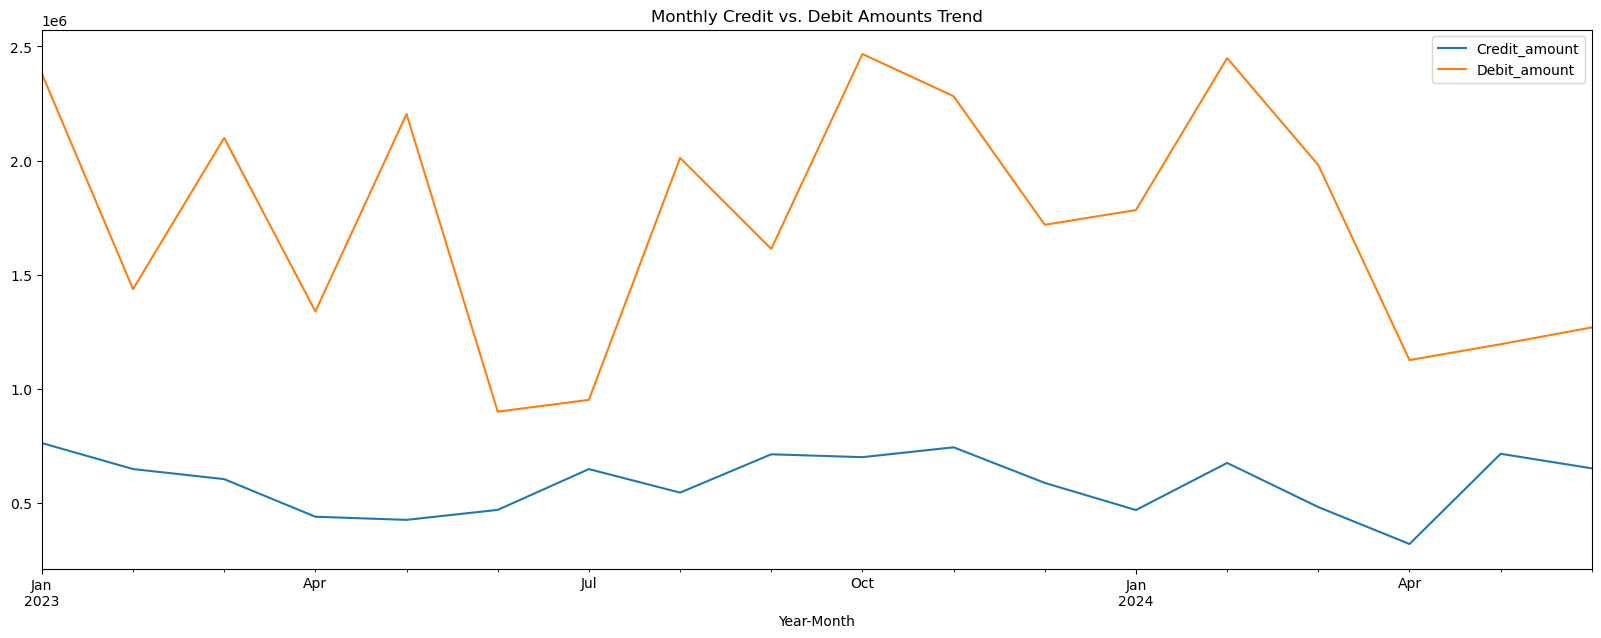

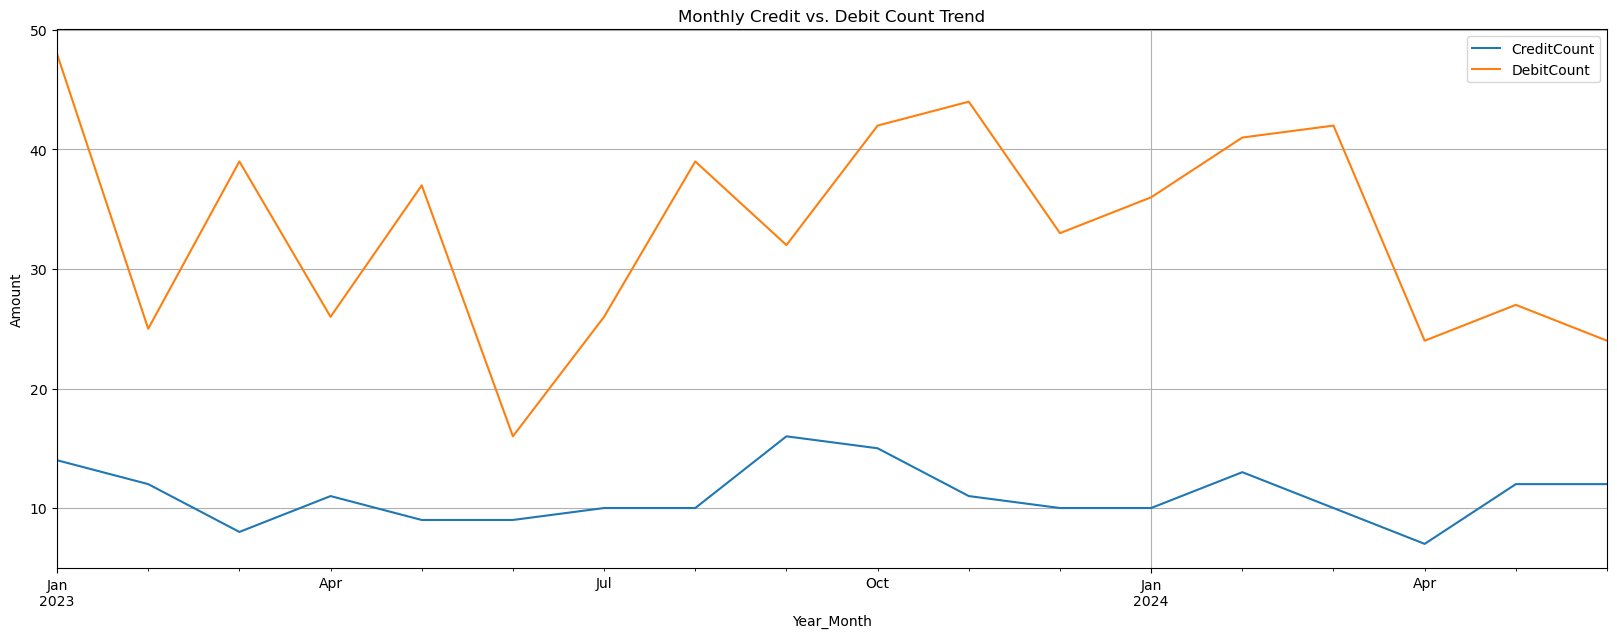

In [13]:
############ Task 2.2 - Plot trends in total credits vs. debits over time.  ###########################
import matplotlib.pyplot as plt

year_month_summary = df.groupby(df['Year-Month']).agg({
    'Credit' : 'sum',
    'Credit_amount' : 'sum',
    'Debit' : 'sum',
    'Debit_amount' : 'sum',
    'Net_Transaction_volume' : 'sum',
    'TransactionID' : 'count'}).rename(columns={'TransactionID':'Transaction_Frequency','Credit':'CreditCount','Debit':'DebitCount'})
#  Convert the index ('Year-Month') into a regular column within a new DataFrame
plot_trend = year_month_summary.reset_index()
plot_trend.plot(kind='line', x ='Year-Month' ,y=['Credit_amount', 'Debit_amount'],figsize=(20, 7),
                title='Monthly Credit vs. Debit Amounts Trend')
plot_trend.plot(kind='line', x ='Year-Month' ,y=['CreditCount', 'DebitCount'],figsize=(20, 7),
                title='Monthly Credit vs. Debit Count Trend')
plt.xlabel('Year_Month')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

In [14]:
###########  Task 2.3 - Identify top and bottom performing accounts based on net inflow. ##########################

account_performance  = df.groupby(df['AccountID'])['Net_Transaction_volume'].sum().reset_index()
# Sort the values (ascending=False puts the highest inflow at the top)
#account_performance = account_performance.sort_values(by=['Net_Inflow'],ascending=False)
print(f'\n Top 10 performing accounts based on net inflow')
# nlargest() sorts by the specified column in descending order and picks the top rows
top_10 = account_performance.nlargest(10,["Net_Transaction_volume"])
print(top_10)

print('\n Bottom 10 performing accounts based on net inflow')
# nsmallest() sorts by the specified column in ascending order to find the lowest values
bottom_10=account_performance.nsmallest(10,["Net_Transaction_volume"])
print(bottom_10)


 Top 10 performing accounts based on net inflow
    AccountID  Net_Transaction_volume
92   ACC48501               346856.34
60   ACC33287               189117.76
168  ACC87006               144009.01
100  ACC50817               121389.17
191  ACC99117               121232.30
112  ACC57516               114164.25
186  ACC95774                95668.51
0    ACC10117                84859.44
86   ACC45951                79050.70
56   ACC31902                77717.28

 Bottom 10 performing accounts based on net inflow
    AccountID  Net_Transaction_volume
107  ACC53466              -458593.81
49   ACC29396              -402944.01
118  ACC60432              -383711.52
48   ACC29356              -380884.25
153  ACC78178              -351707.01
55   ACC31539              -351124.97
159  ACC82298              -347376.54
165  ACC83581              -346988.24
185  ACC95164              -340602.16
13   ACC16241              -332325.85


In [15]:
#------------------------------------------------------------------------------------------------------------------------------------------
# Task 2.4 - Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.
#------------------------------------------------------------------------------------------------------------------------------------------

# Sort by Account and Date to calculate gaps
sorted_data = df.sort_values(by=['AccountID','TransactionDate'],ascending=[True,True])

# Calculate the gap in days between transactions for each account
# groupby ensures we only compare dates within the same account
sorted_data['Days_Since_Last_Transaction'] = df.groupby('AccountID')['TransactionDate'].diff().dt.days.fillna(0).abs()

# Identify dormant AccountIDs using .query()
dormant_id = sorted_data.query("Days_Since_Last_Transaction >= 60")['AccountID'].unique()

# Create a summary DataFrame of all unique accounts
account_status = pd.DataFrame({'AccountID': df['AccountID'].unique()})
# np.where(condition, value_if_true, value_if_false)
account_status['Status'] = np.where(account_status['AccountID'].isin(dormant_id), 'Inactive/Dormant', 'Active')
account_status

#print(account_status['Status'].value_counts())



,AccountID,Status
0,ACC12334,Inactive/Dormant
1,ACC52650,Inactive/Dormant
2,ACC45101,Inactive/Dormant
3,ACC88252,Inactive/Dormant
4,ACC21878,Inactive/Dormant
...,...,...
189,ACC19178,Active
190,ACC62809,Active
191,ACC64785,Active
192,ACC26956,Active


In [16]:
# This pd.merge() combine the original transaction data with the newly created account status information
df_merged = pd.merge(df,account_status,on='AccountID',how='left')
df_merged


,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,TenureMonths,Month,Year,Year-Month,Credit,Credit_amount,Debit,Debit_amount,Net_Transaction_volume,Status
0,33,CUST6549,ACC12334,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 1,2023-10-21,...,200,10,2023,2023-10,0,0.00,1,87480.05,-87480.05,Inactive/Dormant
1,177,CUST2942,ACC52650,Credit,Withdrawal,Home Loan,Firm A,East,Manager 3,2023-06-20,...,47,6,2023,2023-06,0,0.00,1,20315.75,-20315.75,Inactive/Dormant
2,178,CUST6776,ACC45101,Current,Deposit,Personal Loan,Firm C,South,Manager 3,2023-01-02,...,109,1,2023,2023-01,1,10484.57,0,0.00,10484.57,Inactive/Dormant
3,173,CUST2539,ACC88252,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,2023-07-25,...,103,7,2023,2023-07,0,0.00,1,45122.27,-45122.27,Inactive/Dormant
4,67,CUST2626,ACC21878,Savings,Withdrawal,Home Loan,Firm C,Central,Manager 4,2023-07-25,...,234,7,2023,2023-07,0,0.00,1,42360.80,-42360.80,Inactive/Dormant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,11,CUST8461,ACC60432,Current,Withdrawal,Credit Card,Firm E,Central,Manager 3,2023-02-17,...,217,2,2023,2023-02,0,0.00,1,119878.30,-119878.30,Inactive/Dormant
796,44,CUST1121,ACC41829,Credit,Withdrawal,Personal Loan,Firm C,East,Manager 4,2023-10-26,...,78,10,2023,2023-10,0,0.00,1,97933.34,-97933.34,Inactive/Dormant
797,160,CUST3059,ACC28292,Current,Payment,Mutual Fund,Firm E,South,Manager 4,2023-05-11,...,215,5,2023,2023-05,0,0.00,1,63072.38,-63072.38,Inactive/Dormant
798,37,CUST1042,ACC28295,Current,Payment,Personal Loan,Firm E,West,Manager 3,2023-03-26,...,238,3,2023,2023-03,0,0.00,1,25289.82,-25289.82,Inactive/Dormant


In [17]:
df_merged['Status'].isna().sum()

np.int64(0)

# Task 3: Customer Profile Building
* Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. Do not forget to mention the rubric in the headings.
* Segment customers by average balance and transaction volume.
* Create profiles for:
        1.  High-net inflow accounts
        2.  High-frequency low-balance accounts
        3.  Accounts with negative or near-zero balances

In [18]:
## Task: 3.1 - Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. Do not forget to mention the rubric in the headings.##

account_activity = (df.groupby('AccountID')['TransactionID'].count().
                    reset_index().rename(columns = {'TransactionID':'TransactionFrequency'}))
# Rubric: Based on TransactionCount/TransactionFrequency (Number of transactions)
# HIGH: >= 75th percentile (top 25%)
# MEDIUM: 25th to 75th percentile (middle 50%)
# LOW: < 25th percentile (bottom 25%)
Low = account_activity['TransactionFrequency'].quantile(0.25)
High = account_activity['TransactionFrequency'].quantile(0.75)
Medium = High - Low
# Create a new column Activity_Levels by categorizing the TransactionFrequency
# The .apply() method evaluates each row based on the defined rubric
account_activity['Activity_Levels']=account_activity['TransactionFrequency'].apply(lambda x : "High" if x>= High else("Medium" if x == Medium else "Low"))
account_activity


,AccountID,TransactionFrequency,Activity_Levels
0,ACC10117,4,Low
1,ACC10996,5,High
2,ACC11062,2,Medium
3,ACC11188,5,High
4,ACC11285,3,Low
...,...,...,...
189,ACC97225,3,Low
190,ACC97411,2,Medium
191,ACC99117,3,Low
192,ACC99409,4,Low


In [19]:
df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths', 'Month', 'Year', 'Year-Month', 'Credit',
       'Credit_amount', 'Debit', 'Debit_amount', 'Net_Transaction_volume'],
      dtype='object')

In [20]:
######### Task: 3.2 - Segment customers by average balance and transaction volume.#######################
segment_customers = df.groupby('CustomerID').agg(
    {'AccountBalance':'mean',
     'Net_Transaction_volume': 'sum'}).reset_index().rename(columns = {'AccountBalance':'AvgBalance','Net_Transaction_volume':'TransactionVolume'})

Avg_High_Bal = segment_customers["AvgBalance"].quantile(0.75)
Avg_Low_Bal = segment_customers["AvgBalance"].quantile(0.25)

high_volume = segment_customers["TransactionVolume"].quantile(0.75)
low_volume = segment_customers["TransactionVolume"].quantile(0.25)

def segmentation(data):
    if data["AvgBalance"] >= Avg_High_Bal and data['TransactionVolume'] >= high_volume:
        return "High Value Customer"
    elif data["AvgBalance"] <= Avg_Low_Bal and data['TransactionVolume'] <= low_volume:
        return "Low Value Customer"
    else:
        return "Avg Value Customer"

segment_customers["Segmentation Customer Value"] = segment_customers.apply(segmentation,axis=1)
segment_customers


,CustomerID,AvgBalance,TransactionVolume,Segmentation Customer Value
0,CUST1042,80435.17,-284936.86,Avg Value Customer
1,CUST1114,60127.89,-268029.67,Low Value Customer
2,CUST1121,83213.47,-398205.12,Avg Value Customer
3,CUST1189,63648.89,-117339.42,Avg Value Customer
4,CUST1223,88186.20,29853.69,High Value Customer
...,...,...,...,...
183,CUST9683,68647.63,-272292.28,Avg Value Customer
184,CUST9731,81032.51,-34485.37,Avg Value Customer
185,CUST9754,86529.58,-104550.32,Avg Value Customer
186,CUST9843,70615.41,21078.05,Avg Value Customer


In [21]:
##### Task 3.3 - Create profiles for #######
# 1. High-net inflow accounts
# 2. High-frequency low-balance accounts
# 3. Accounts with negative or near-zero balances

# 3.3.1 - High-net inflow accounts:
Profiled_accounts = (df.groupby('AccountID')['Net_Transaction_volume'].sum().
                            sort_values(ascending=False).reset_index().
                            rename(columns = {'Net_Transaction_volume':'Net_Inflow'}))
top_20_percentile = Profiled_accounts['Net_Inflow'].quantile(0.80)
Profiled_accounts['High_Net_Inflow'] =np.where(Profiled_accounts['Net_Inflow']>= top_20_percentile,True,False)
#Profiled_accounts
High_net_inflow_accounts = Profiled_accounts[Profiled_accounts['High_Net_Inflow']== True]
High_net_inflow_accounts

,AccountID,Net_Inflow,High_Net_Inflow
0,ACC48501,346856.34,True
1,ACC33287,189117.76,True
2,ACC87006,144009.01,True
3,ACC50817,121389.17,True
4,ACC99117,121232.30,True
5,ACC57516,114164.25,True
6,ACC95774,95668.51,True
7,ACC10117,84859.44,True
8,ACC45951,79050.70,True
9,ACC31902,77717.28,True


In [22]:
# Task 3.3.2 - High-frequency low-balance accounts---------
High_fre_low_balance = (df.groupby("AccountID").agg({
    'TransactionID': 'count',
    'AccountBalance':'mean'})
                        .reset_index()
                        .rename(columns={"TransactionID":"TransactionCount",
                                        'AccountBalance':'AvgBalance'}))
#High_fre_low_balance

top_20_percentile_high_freq = High_fre_low_balance["TransactionCount"].quantile(0.80)
bottom_30_percentile_low_balnce = High_fre_low_balance["AvgBalance"].quantile(0.30)
High_fre_low_balance["HighFreq LowBal"] =np.where((
    High_fre_low_balance["TransactionCount"] >=top_20_percentile_high_freq) & (
    High_fre_low_balance["AvgBalance"]<= bottom_30_percentile_low_balnce),True,False)

High_fre_low_balance_accounts = High_fre_low_balance[High_fre_low_balance['HighFreq LowBal']== True]
High_fre_low_balance_accounts

,AccountID,TransactionCount,AvgBalance,HighFreq LowBal
29,ACC23736,7,60801.53,True
42,ACC28292,10,51228.00,True
55,ACC31539,6,45185.94,True
60,ACC33287,8,59331.98,True
98,ACC49774,7,54898.79,True
114,ACC57700,8,60537.13,True
120,ACC61926,6,53209.10,True
141,ACC74631,6,50478.58,True
156,ACC80131,6,61459.22,True
164,ACC83269,7,48187.87,True


In [23]:
# Task 3.3.3 - Accounts with negative or near-zero balances
accounts_filtering = (df.groupby("AccountID")["AccountBalance"].mean().reset_index().
                      rename(columns={'AccountBalance':'AvgBalance'}))
accounts_with_zer_negative=accounts_filtering[accounts_filtering['AvgBalance'] < 10]
accounts_with_zer_negative

,AccountID,AvgBalance
20,ACC19178,-1541.18


# Task 4: Financial Risk Identification
1. Track accounts with frequent large withdrawals or overdrafts.
2. Calculate balance volatility using standard deviation or coefficient of variation.
3. Use IQR or z-score methods to detect anomalies.
4. Highlight customers with irregular or suspicious transaction behavior.


In [24]:
######### Task:4.1 - Track accounts with frequent large withdrawals or overdrafts ############################
withdrawals_rows = df[df["TransactionType"]== "Withdrawal"]

large_withdrawals_summary = withdrawals_rows.groupby("AccountID").agg(
    withdrawals_counts = ("TransactionAmount","count"),                          # Frequency of withdrawals
    total_withdrawals_amount = ("TransactionAmount","sum")).reset_index()       # Total amount withdrawn
#large_withdrawals_summary
top_25_percentile_withdrawals_count = large_withdrawals_summary['withdrawals_counts'].quantile(0.75)
top_25_percentile_withdrawals_amount = large_withdrawals_summary["total_withdrawals_amount"].quantile(0.75)

accounts_with_frequent_large_withdrawals = large_withdrawals_summary[
    (large_withdrawals_summary['withdrawals_counts']>= top_25_percentile_withdrawals_count)
    &
    (large_withdrawals_summary['total_withdrawals_amount']>=top_25_percentile_withdrawals_amount)]

print(f"--- Accounts with Frequent Large Withdrawals ---")
accounts_with_frequent_large_withdrawals



--- Accounts with Frequent Large Withdrawals ---


,AccountID,withdrawals_counts,total_withdrawals_amount
4,ACC12334,3,150768.24
5,ACC15228,2,148019.43
8,ACC16241,5,307211.01
9,ACC16664,4,159687.75
10,ACC17688,2,149378.94
12,ACC18177,3,138575.63
20,ACC25132,3,174543.18
24,ACC28292,3,146360.99
28,ACC29356,3,140846.80
32,ACC31539,2,182166.94


In [25]:
###### Task: 4.2 - Calculate balance volatility using standard deviation or coefficient of variation.#############

# Calculate coefficient of variation for each account
# Formula: CV = (Standard Deviation / Mean) * 100
# Interpretation: Higher CV = More volatile (risky)

balance_volatility = df.groupby('AccountID').agg({'AccountBalance': ['std', 'mean', 'min', 'max'],
    'CustomerID': 'first','AccountType': 'first'})

balance_volatility.columns = ['BalanceStd', 'BalanceMean', 'BalanceMin', 'BalanceMax', 'CustomerID', 'AccountType']

# Calculate Coefficient of Variation and Handle division by zero
balance_volatility['CoefficientOfVariation'] = np.where(balance_volatility['BalanceMean'] != 0,
        (balance_volatility['BalanceStd'] / balance_volatility['BalanceMean'].abs()) * 100,0)

# Calculate Balance Range
balance_volatility['BalanceRange'] = balance_volatility['BalanceMax'] - balance_volatility['BalanceMin']

# High volatility threshold (top 25%)
high_volatility_threshold = balance_volatility['CoefficientOfVariation'].quantile(0.75)

high_volatility_accounts = balance_volatility[balance_volatility['CoefficientOfVariation']
                                              >= high_volatility_threshold]

print(f"\n BALANCE VOLATILITY ANALYSIS:")
print(f" High Volatility Threshold (CV >= {high_volatility_threshold:.2f}%)")
print(f" High volatility accounts: {len(high_volatility_accounts)}")
print(f"\n  Top 10 Most Volatile Accounts:")
print(high_volatility_accounts.nlargest(10, 'CoefficientOfVariation')[
    ['BalanceStd', 'BalanceMean', 'CoefficientOfVariation', 'BalanceRange']])


 BALANCE VOLATILITY ANALYSIS:
 High Volatility Threshold (CV >= 57.29%)
 High volatility accounts: 45

  Top 10 Most Volatile Accounts:
           BalanceStd  BalanceMean  CoefficientOfVariation  BalanceRange
AccountID                                                               
ACC29477     53336.38     34047.75                  156.65     101994.48
ACC70314     49242.72     32004.16                  153.86     119725.02
ACC45968     50474.31     44919.54                  112.37      71381.46
ACC21878     70517.53     67726.45                  104.12      99726.84
ACC58667     58637.34     57596.21                  101.81     147760.48
ACC83005     24240.20     25651.79                   94.50      44544.22
ACC55331     41560.54     46130.68                   90.09      87567.97
ACC49774     45904.13     54898.79                   83.62     141556.43
ACC23736     48785.76     60801.53                   80.24     138278.61
ACC33287     47466.41     59331.98                   80.00  

In [26]:
##### Task: 4.3 - Use IQR or z-score methods to detect anomalies ############

# IQR Method for Anomaly Detection
# IQR = Q3 - Q1
# Outliers: Values < Q1 - 1.5*IQR or > Q3 + 1.5*IQR

Q3_amount = df['TransactionAmount'].quantile(0.75)
Q1_amount = df['TransactionAmount'].quantile(0.25)
IQR_amount = Q3_amount - Q1_amount

upper_bound = Q3_amount + 1.5 * IQR_amount
lower_bound = Q1_amount - 1.5 * IQR_amount

anomalies_transaction_amount = df[(df['TransactionAmount'] >= upper_bound) | (df['TransactionAmount']<= lower_bound)]

print(f"\n Anomalies In TransactionAmount:")
print(f"    Q1: ${Q1_amount:,.2f}, Q3: ${Q3_amount:,.2f}, IQR: ${IQR_amount:,.2f}")
print(f"    Lower Bound: ${lower_bound:,.2f}")
print(f"    Upper Bound: ${upper_bound:,.2f}")
print(f"  Anomalous balance records: {len(anomalies_transaction_amount)}")


 Anomalies In TransactionAmount:
    Q1: $31,692.00, Q3: $71,913.39, IQR: $40,221.39
    Lower Bound: $-28,640.08
    Upper Bound: $132,245.48
  Anomalous balance records: 0


In [27]:
# Z-Score Method for Anomaly Detection

# Z-score = (Value - Mean) / Std Dev
# Threshold: |Z-score| > 3 (99.7% confidence)

print(f"\n ANOMALY DETECTION (Z-Score Method, threshold = 3):")


# Calculate Z-scores
df['TransactionAmount_ZScore'] = np.abs(stats.zscore(df['TransactionAmount']))
df['AccountBalance_ZScore'] = np.abs(stats.zscore(df['AccountBalance']))
df['RiskScore_ZScore'] = np.abs(stats.zscore(df['RiskScore']))

# Detect anomalies
z_score_threshold = 3
z_anomalies = df[(df['TransactionAmount_ZScore'] > z_score_threshold) |(df['AccountBalance_ZScore'] > z_score_threshold) |
    (df['RiskScore_ZScore'] > z_score_threshold)].copy()

print(f"  Z-Score Threshold: {z_score_threshold}")
print(f"  Anomalous records detected in TransactionAmount: {len(df[df['TransactionAmount_ZScore'] > z_score_threshold])}")
print(f"  Anomalous records detected in AccountBalance: {len(df[df['AccountBalance_ZScore'] > z_score_threshold])}")
print(f"  Anomalous records detected in RiskScore: {len(df[df['RiskScore_ZScore'] > z_score_threshold])}")
if len(z_anomalies) > 0:
    print(f"\n  Sample anomalies:")
    print(z_anomalies[['AccountID', 'TransactionAmount', 'AccountBalance', 'RiskScore',
                       'TransactionAmount_ZScore', 'AccountBalance_ZScore']].head(10))



 ANOMALY DETECTION (Z-Score Method, threshold = 3):
  Z-Score Threshold: 3
  Anomalous records detected in TransactionAmount: 0
  Anomalous records detected in AccountBalance: 3
  Anomalous records detected in RiskScore: 2

  Sample anomalies:
    AccountID  TransactionAmount  AccountBalance  RiskScore  \
31   ACC18140           45680.91        62110.37      -0.30   
89   ACC34821           63709.51       175247.54       0.50   
166  ACC82381            4236.08       141381.53      -0.39   
215  ACC70314           54119.73       -31597.85       0.59   
746  ACC33287           69752.55       -37293.60       0.71   

     TransactionAmount_ZScore  AccountBalance_ZScore  
31                       0.24                   0.30  
89                       0.41                   3.02  
166                      1.73                   2.03  
215                      0.07                   3.05  
746                      0.63                   3.22  


In [28]:
### Task: 4.4 - Highlight customers with irregular or suspicious transaction behavior. ########
customers_summary = df.groupby('CustomerID').agg({'TransactionAmount':['mean','std','count']}).reset_index()
customers_summary.columns = ['CustomerID','TransactionAmountMean','TransactionAmountstd','TransactionAmountcount']
#customers_summary
# 2. Identify high-frequency users (top 5%)
frequ_threshold = customers_summary['TransactionAmountcount'].quantile(0.95)
freq_users_ids = customers_summary[customers_summary['TransactionAmountcount'] > frequ_threshold]['CustomerID'].fillna(0)

# 3. Flag suspicious transactions (Individual amounts > Mean + 3*Std for that customer)
# Merge summary stats back to the original dataframe
df = df.merge(customers_summary, on='CustomerID', how='left')

# Flag transactions that are extreme outliers for that specific customer
df['Is_Suspicious_Amount'] = df['TransactionAmount'] > (df['TransactionAmountMean'] + 3 * df['TransactionAmountstd'])

# 4. Identify suspicious customers (High frequency OR has at least one outlier transaction)
suspicious_mask = (df['CustomerID'].isin(freq_users_ids)) | (df['Is_Suspicious_Amount'] == True)
suspicious_customer_df = df[suspicious_mask]

# Show final results
suspicious_customer_df[['CustomerID','Is_Suspicious_Amount']]

,CustomerID,Is_Suspicious_Amount
13,CUST8529,False
30,CUST5174,False
33,CUST5174,False
47,CUST8529,False
58,CUST3015,False
80,CUST3015,False
81,CUST5174,False
99,CUST4373,False
120,CUST8529,False
122,CUST8772,False


# Task 5: Visualisation
 * Conduct extensive exploratory data analysis with attractive visualizations for your findings


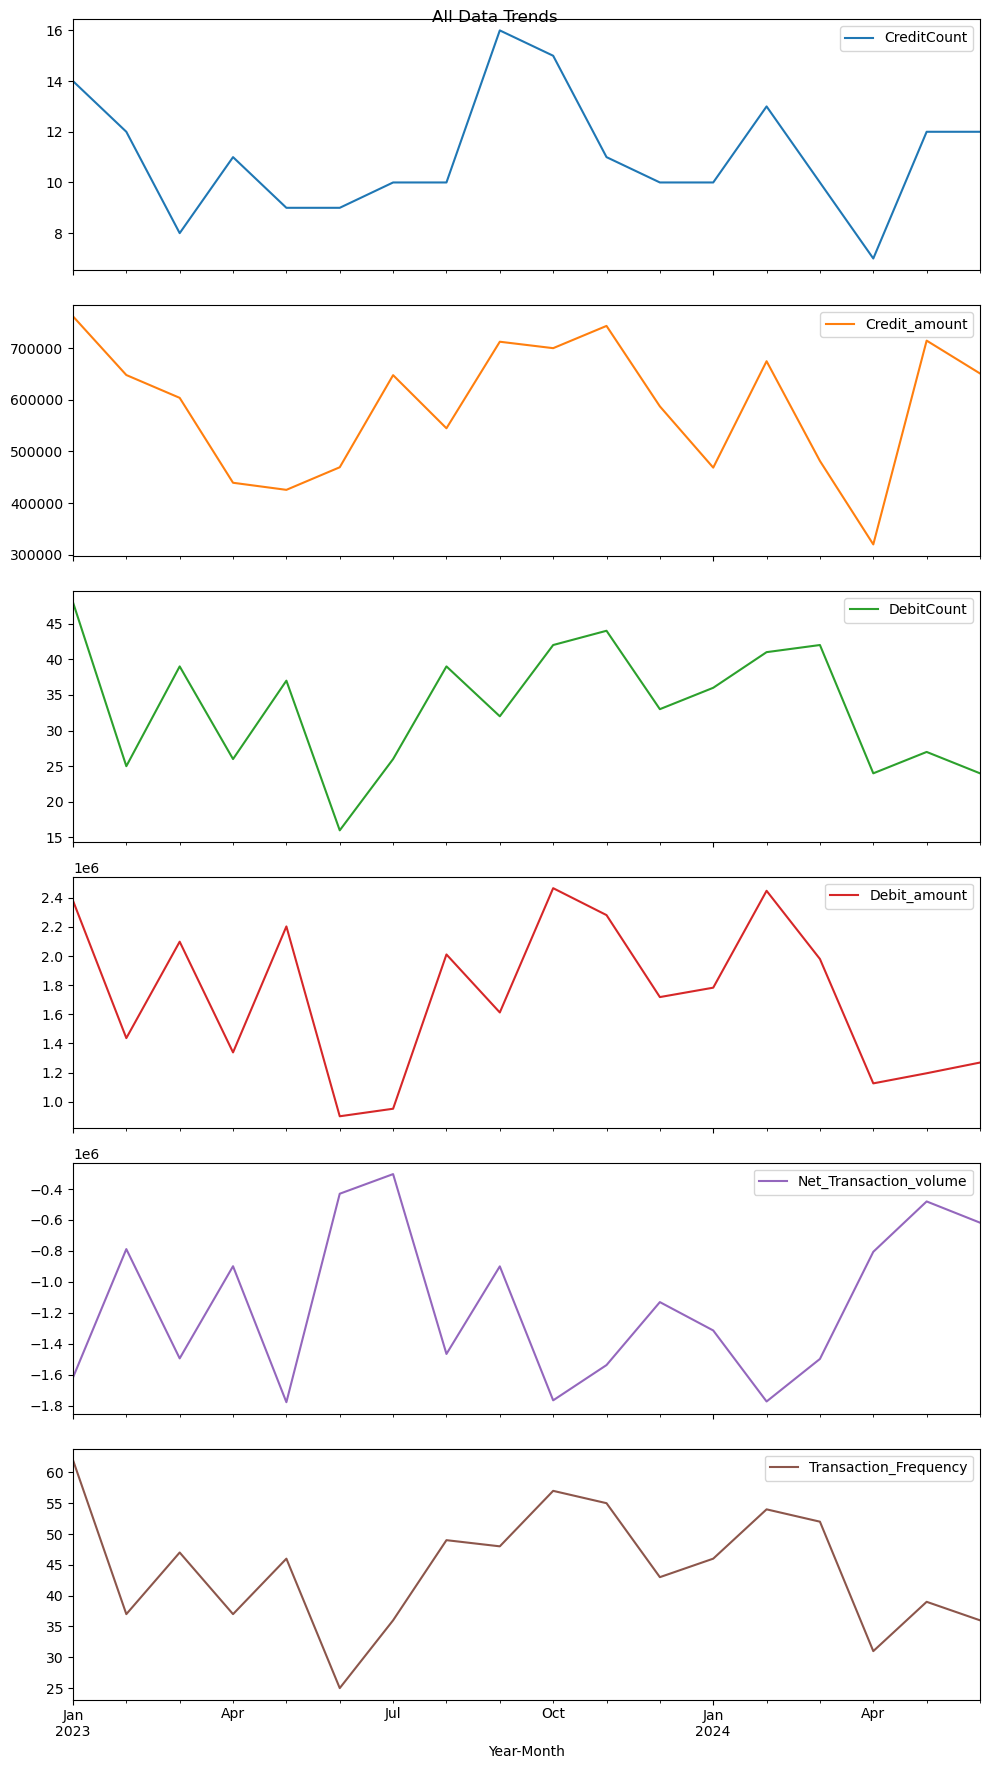

In [29]:



import matplotlib.pyplot as plt
plt_Transaction = year_month_summary.reset_index()
# Generates individual line charts for all numeric columns in a 2-column grid
year_month_summary.plot(subplots=True, figsize=(10, 18), title="All Data Trends")
plt.tight_layout()
plt.show()


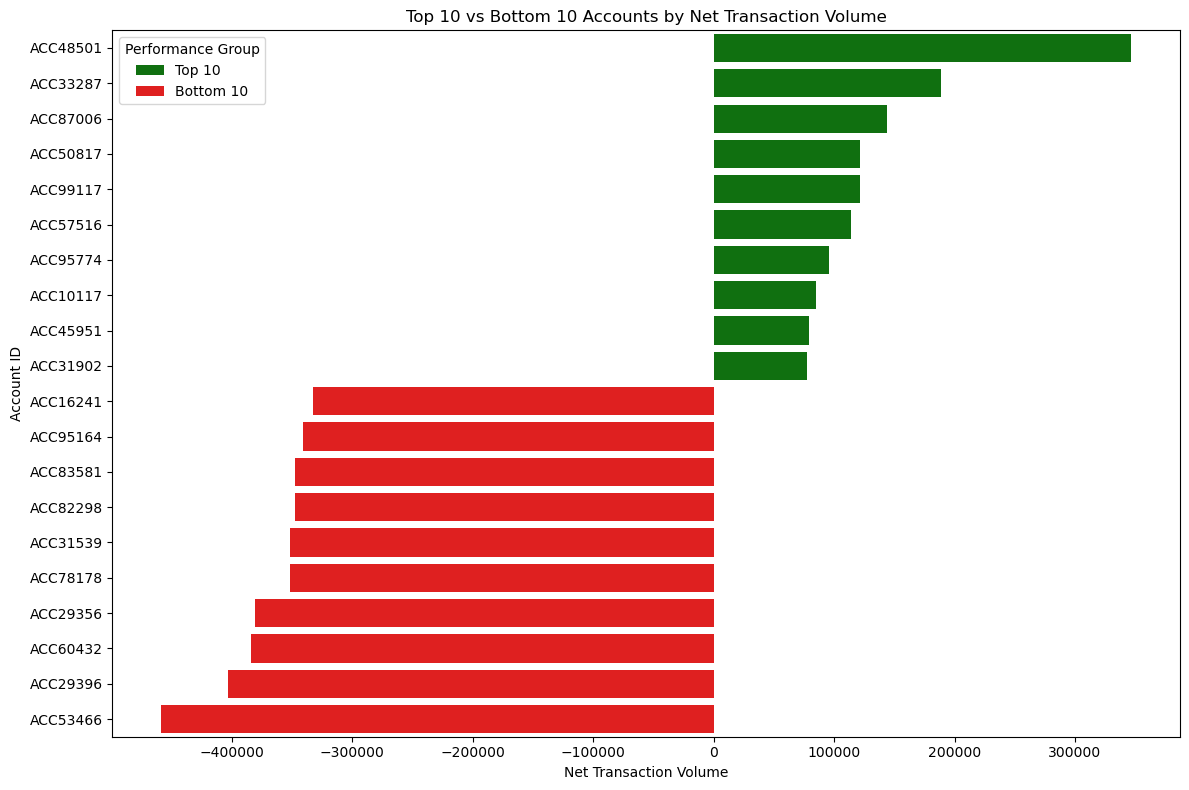

In [30]:
# Top 10 and bottom 10 Acccounts by net trasnsaction volume
# Add group labels and combine
top_10 = top_10.assign(Group='Top 10')
bottom_10 = bottom_10.assign(Group='Bottom 10')
plot_df = pd.concat([top_10, bottom_10], ignore_index=True)

# Sort for better ordering (bottom to top)
plot_df_sorted = plot_df.sort_values('Net_Transaction_volume',ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=plot_df_sorted, x='Net_Transaction_volume', y='AccountID', hue='Group',
    palette={'Top 10': 'green', 'Bottom 10': 'red'})
plt.title('Top 10 vs Bottom 10 Accounts by Net Transaction Volume')
plt.xlabel('Net Transaction Volume')
plt.ylabel('Account ID')
plt.legend(title='Performance Group')
plt.tight_layout()
plt.show()

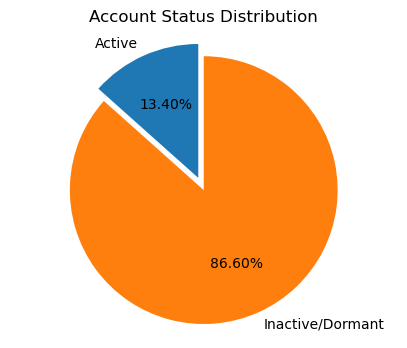

In [31]:
# Account Status Distribution
plt_account_status = account_status.groupby("Status")["AccountID"].count()

plt.figure(figsize=(5, 4))
plt.pie( plt_account_status.values,  # counts/sizes
    labels=plt_account_status.index,  # status names
    autopct='%.2f%%',  # show percentages
    startangle=90,
    explode=(0.1,0))   # Create gap
plt.title('Account Status Distribution')
plt.axis('equal')  # Equal aspect ratio
plt.show()


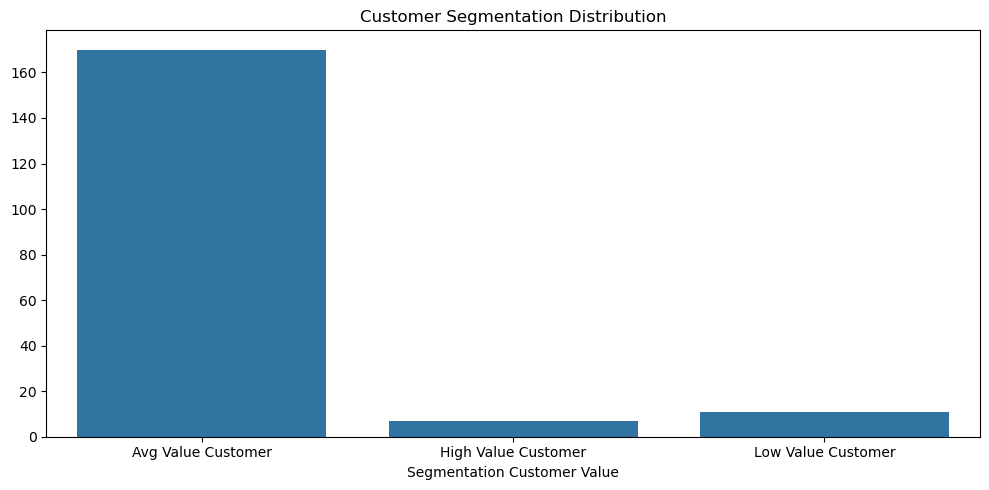

In [32]:
import seaborn as sns
plt_segment_customers = segment_customers.groupby("Segmentation Customer Value")['CustomerID'].count()
plt.figure(figsize=(10,5))
sns.barplot(x=plt_segment_customers.index, y=plt_segment_customers.values)

plt.title('Customer Segmentation Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

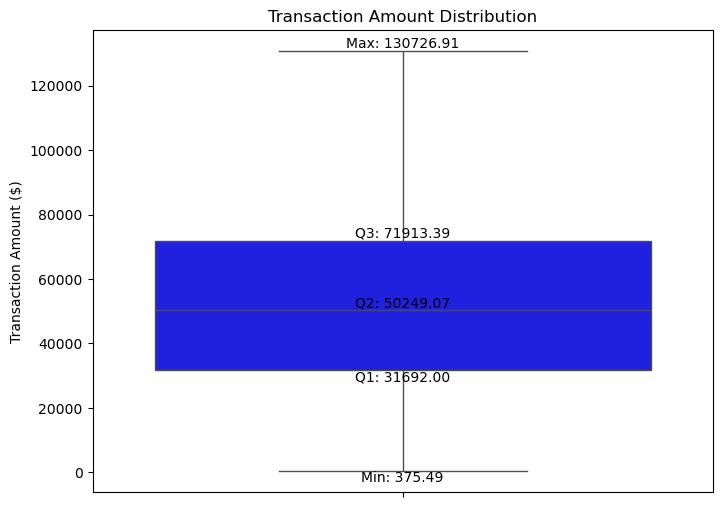

In [33]:
import seaborn as sns
plt.figure(figsize=(8, 6))
T_plot = sns.boxplot(y= df['TransactionAmount'],color="Blue")

plt.title('Transaction Amount Distribution')
plt.ylabel('Transaction Amount ($)')
#plt.show()

# ---- Calculate statistics ----
data = df["TransactionAmount"].dropna()

q1 = np.percentile(data, 25)
q2 = np.percentile(data, 50)
q3 = np.percentile(data, 75)
min_val = data.min()
max_val = data.max()

# ---- Add labels ----
T_plot.text(0,q2, f"Q2: {q2:.2f}", ha="center", va="bottom")
T_plot.text(0, q1, f"Q1: {q1:.2f}", ha="center", va="top")
T_plot.text(0, q3, f"Q3: {q3:.2f}", ha="center", va="bottom")
T_plot.text(0, min_val, f"Min: {min_val:.2f}", ha="center", va="top")
T_plot.text(0, max_val, f"Max: {max_val:.2f}", ha="center", va="bottom")

plt.show()

# Task 6: Hypothesis Testing
* Test whether high-volume transaction accounts have statistically higher average
balances than low-volume accounts.
* Conduct hypothesis testing based on segmentation.

In [34]:
### Task:6.1-Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts ###
from scipy import stats

avg_balance = df['Net_Transaction_volume'].mean()
high_volume_taccounts = df[df['Net_Transaction_volume'] > avg_balance]["AccountBalance"]
low_volume_taccounts = df[df['Net_Transaction_volume'] <= avg_balance]['AccountBalance']

# Two-sample t-test (independent samples)
t_stat, p_value = stats.ttest_ind(high_volume_taccounts, low_volume_taccounts, equal_var=False)  # Welch's t-test

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("Reject H0: High-volume accounts have statistically higher average balances.")
else:
    print("Fail to reject H0: No significant difference in average balances.")

T-statistic: -0.8970
P-value: 0.3700
Fail to reject H0: No significant difference in average balances.


In [35]:
df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths', 'Month', 'Year', 'Year-Month', 'Credit',
       'Credit_amount', 'Debit', 'Debit_amount', 'Net_Transaction_volume',
       'TransactionAmount_ZScore', 'AccountBalance_ZScore', 'RiskScore_ZScore',
       'TransactionAmountMean', 'TransactionAmountstd',
       'TransactionAmountcount', 'Is_Suspicious_Amount'],
      dtype='object')

In [36]:
######################### Task 6.2 - Conduct hypothesis testing based on segmentation. ##########################

high_bal = segment_customers[segment_customers['Segmentation Customer Value'] == 'High Value Customer']['AvgBalance'].dropna()
low_bal = segment_customers[segment_customers['Segmentation Customer Value'] == 'Low Value Customer']['AvgBalance'].dropna()

t_value, p_value = stats.ttest_ind(high_bal, low_bal, equal_var=False)
print(f"\n1. AvgBalance (High vs Low): t_value={t_value:.4f}, p_value={p_value:.4f}")
if p_value < 0.05:
    print(" High Value customers have significantly HIGHER average balances")
else:
    print(" No significant difference")



1. AvgBalance (High vs Low): t_value=7.1630, p_value=0.0000
 High Value customers have significantly HIGHER average balances


In [37]:
# ANOVA - All 3 segments differ?
# AvgBalance ANOVA
bal_groups = [group['AvgBalance'].dropna()
              for name, group in segment_customers.groupby('Segmentation Customer Value')]
f_bal, p_anova_bal = stats.f_oneway(*bal_groups)

print(f"\n ANOVA AvgBalance (all segments): F={f_bal:.4f}, p={p_anova_bal:.4f}")
if p_anova_bal < 0.05:
    print("Segments significantly differ in average balance")


 ANOVA AvgBalance (all segments): F=17.1398, p=0.0000
Segments significantly differ in average balance


# Video Link

https://drive.google.com/file/d/1tjD3398wQ7lneN_CFds-UCbjt9MTh0A8/view?usp=sharing